In [ ]:
!pip uninstall torch torchvision -y
!pip cache purge
!pip install torch torchvision numpy==1.26.4 --no-cache-dir

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Files removed: 0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 295.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.2/821.2 MB 185.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 261.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 311.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 266.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 406.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 260.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 254.4 MB/s et

In [1]:
!pip uninstall torch torchvision torchaudio fastai thinc spacy numpy torchcam tensorflow numba timm -y
!pip cache purge
!pip install torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 fastai==2.7.19 thinc==8.2.5 spacy==3.7.5 numpy==1.26.4 torchcam==0.4.0 tensorflow==2.18.0 numba==0.60.0 timm --no-cache-dir

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Found existing installation: fastai 2.7.19
Uninstalling fastai-2.7.19:
  Successfully uninstalled fastai-2.7.19
Found existing installation: thinc 8.3.6
Uninstalling thinc-8.3.6:
  Successfully uninstalled thinc-8.3.6
Found existing installation: spacy 3.8.7
Uninstalling spacy-3.8.7:
  Successfully uninstalled spacy-3.8.7
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: tensorflow 2.18.0
Uninstalling tensorflow-2.18.0:
  Successfully uninstalled tensorflow-2.18.0
Found existing installation: numba 0.6

In [2]:
!pip show torch
!pip show torchvision
!pip show numpy

Name: torch
Version: 2.6.0+cu124
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /usr/local/lib/python3.11/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchaudio, torchdata, torchvision
Name: torchvision
Version: 0.21.0+cu124
Summary: image and video datasets and models for torch deep learning
Home-page: https://github.com/pytorch/vision
Author: PyTorch Core Team
Author-email: soumith@pytorch.org
License: BSD
Location: /usr/local/lib/python3.11

In [1]:
import torch
# ---------------------- 2. Device Configuration ----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)
if device.type == 'cuda':
    print("🚀 GPU Name:", torch.cuda.get_device_name(0))
else:
    print("⚠️ WARNING: GPU not available, training on CPU")

✅ Using device: cuda
🚀 GPU Name: Tesla T4


In [3]:
import kagglehub
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

# Download the dataset
path = kagglehub.dataset_download("ninadaithal/imagesoasis")
print("Path to dataset files:", path)

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load dataset
dataset = datasets.ImageFolder(root=path, transform=transform)

# Split dataset
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_ds, val_ds, test_ds = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

# Dataloaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

100%|██████████| 1.23G/1.23G [01:00<00:00, 21.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ninadaithal/imagesoasis/versions/1


In [4]:
import torch.nn as nn
from torchvision.models import resnet18

# Load a pretrained ResNet18 model
model = resnet18(pretrained=True)

# Modify the final classification layer to match your dataset (3 classes)
model.fc = nn.Linear(model.fc.in_features, 3)

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 210MB/s]


In [5]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [6]:
def train(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    for epoch in range(epochs):
        model.train()
        train_loss, correct = 0.0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = correct / len(train_loader.dataset)

        # Validation
        model.eval()
        val_correct = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")


In [7]:
train(model, train_loader, val_loader, criterion, optimizer, epochs=2)

Epoch 1: Train Loss=18.2110, Train Acc=0.9973, Val Acc=1.0000
Epoch 2: Train Loss=0.1873, Train Acc=1.0000, Val Acc=1.0000


In [8]:
def test(model, test_loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            correct += (outputs.argmax(1) == labels).sum().item()

    accuracy = correct / len(test_loader.dataset)
    print(f"Test Accuracy: {accuracy:.4f}")

test(model, test_loader)


Test Accuracy: 1.0000


In [9]:
!pip install grad-cam --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 110.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 99.3 MB/s 

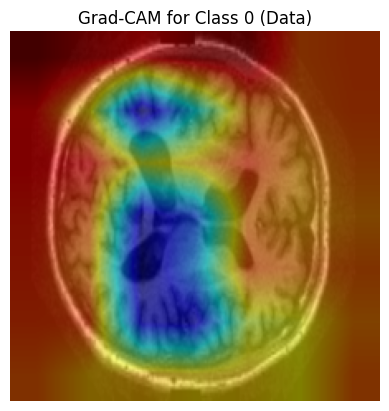

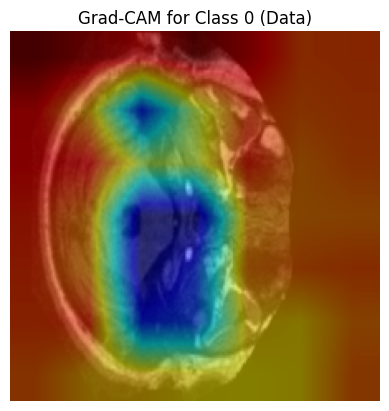

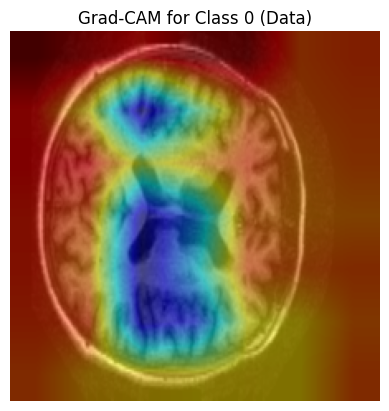

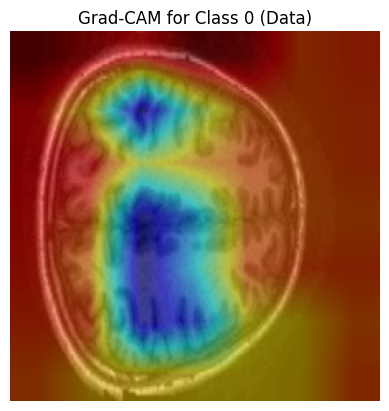

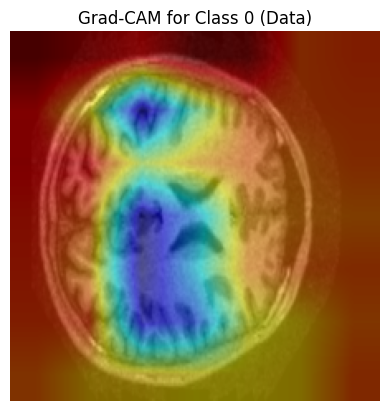

In [10]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt

# Set up Grad-CAM
model.eval()
model.to(device)
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Get one batch
images, labels = next(iter(test_loader))

# Loop through first 5 images in the batch
for i in range(5):
    input_tensor = images[i].unsqueeze(0).to(device)
    label = labels[i].item()

    # Normalize image for visualization
    rgb_image = images[i].permute(1, 2, 0).cpu().numpy()
    rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())

    # Run Grad-CAM
    targets = [ClassifierOutputTarget(label)]
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    # Overlay heatmap
    visualization = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)

    # Show image
    plt.imshow(visualization)
    plt.title(f"Grad-CAM for Class {label} ({dataset.classes[label]})")
    plt.axis('off')
    plt.show()


In [11]:
import torch
import torch.nn as nn
from torchvision import models
from einops import rearrange, repeat

class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super(TransformerEncoderBlock, self).__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = x + attn_output
        x = self.norm1(x)
        mlp_output = self.mlp(x)
        x = x + mlp_output
        x = self.norm2(x)
        return x

class CNNTransformerHybrid(nn.Module):
    def __init__(self, num_classes=3, embed_dim=512, num_heads=8, mlp_dim=2048, num_layers=1):
        super(CNNTransformerHybrid, self).__init__()
        # CNN backbone (use ResNet18 till layer4)
        resnet = models.resnet18(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])  # output: [B, 512, 7, 7]

        self.flatten = nn.Flatten(2)  # [B, 512, 49]
        self.transpose = lambda x: x.permute(2, 0, 1)  # [49, B, 512]

        # Transformer encoder
        self.transformer_layers = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim) for _ in range(num_layers)
        ])

        # Classification head
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        x = self.cnn(x)  # [B, 512, 7, 7]
        x = self.flatten(x)  # [B, 512, 49]
        x = self.transpose(x)  # [49, B, 512]

        for layer in self.transformer_layers:
            x = layer(x)

        x = x.mean(dim=0)  # Global average pooling across sequence
        x = self.head(x)  # [B, num_classes]
        return x


In [12]:
model = CNNTransformerHybrid(num_classes=3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [14]:
train(model, train_loader, val_loader, criterion, optimizer, epochs=2)

Epoch 1: Train Loss=1.5309, Train Acc=0.9996, Val Acc=1.0000
Epoch 2: Train Loss=0.0021, Train Acc=1.0000, Val Acc=1.0000


In [15]:
test(model, test_loader)

Test Accuracy: 1.0000


In [16]:
torch.save(model.state_dict(), "cnn_transformer_hybrid.pth")

In [17]:
import torch
import torch.nn as nn
from torchvision import models
from einops import rearrange, repeat
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super(TransformerEncoderBlock, self).__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = x + attn_output
        x = self.norm1(x)
        mlp_output = self.mlp(x)
        x = x + mlp_output
        x = self.norm2(x)
        return x

class CNNTransformerHybrid(nn.Module):
    def __init__(self, num_classes=3, embed_dim=512, num_heads=8, mlp_dim=2048, num_layers=1):
        super(CNNTransformerHybrid, self).__init__()
        resnet = models.resnet18(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])  # [B, 512, 7, 7]
        self.flatten = nn.Flatten(2)  # [B, 512, 49]
        self.transpose = lambda x: x.permute(2, 0, 1)  # [49, B, 512]

        self.transformer_layers = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim) for _ in range(num_layers)
        ])

        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        x = self.cnn(x)
        x = self.flatten(x)
        x = self.transpose(x)
        for layer in self.transformer_layers:
            x = layer(x)
        x = x.mean(dim=0)
        x = self.head(x)
        return x

# Evaluation Function
def evaluate(model, dataloader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

# Grad-CAM Setup
def run_gradcam(model, dataloader, class_names, device):
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
    model.eval()
    target_layers = [model.cnn[-1]]  # Use last CNN layer
    cam = GradCAM(model=model, target_layers=target_layers)
    images, labels = next(iter(dataloader))
    for i in range(5):
        input_tensor = images[i].unsqueeze(0).to(device)
        label = labels[i].item()
        rgb_image = images[i].permute(1, 2, 0).cpu().numpy()
        rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())
        targets = [ClassifierOutputTarget(label)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
        visualization = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)
        plt.imshow(visualization)
        plt.title(f"Grad-CAM for Class {label} ({class_names[label]})")
        plt.axis('off')
        plt.show()



Classification Report:
              precision    recall  f1-score   support

        Data       1.00      1.00      1.00     12967

    accuracy                           1.00     12967
   macro avg       1.00      1.00      1.00     12967
weighted avg       1.00      1.00      1.00     12967



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


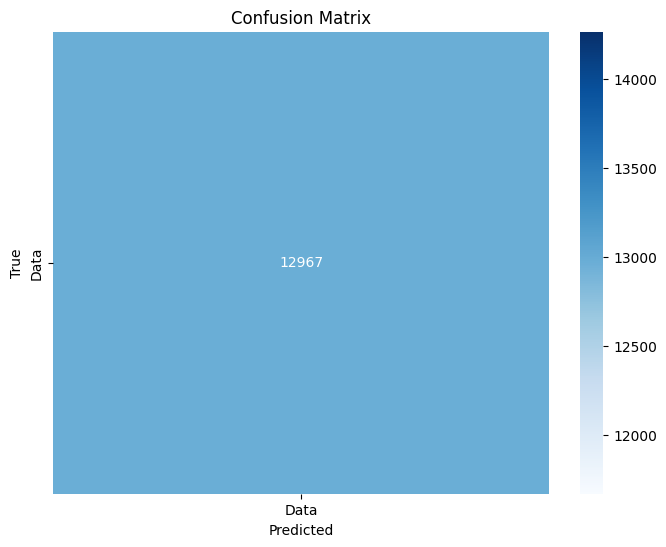

In [18]:
evaluate(model, test_loader, device, dataset.classes)

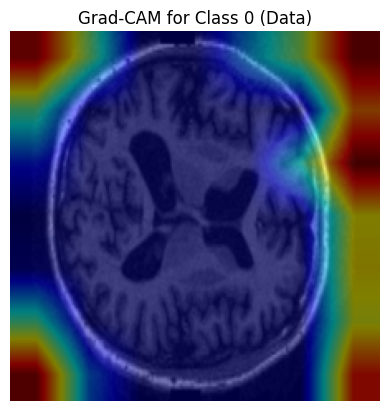

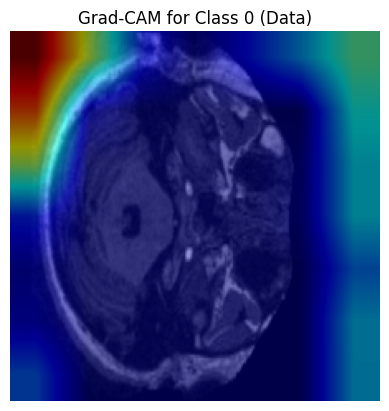

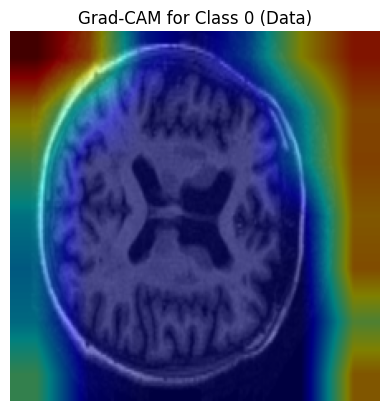

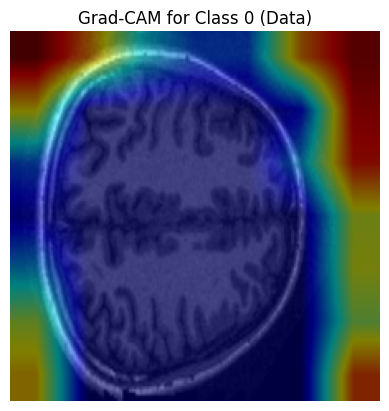

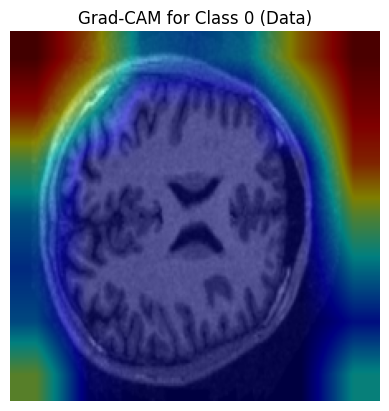

In [19]:
run_gradcam(model, test_loader, dataset.classes, device)

In [20]:
pip install lime shap scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 17.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=f32847ca43a0021fd71aaf9adf56e5bf6eb8e0f8d02afe2229eada2e00cf94a3
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [21]:
# LIME imports
from lime.lime_image import LimeImageExplainer
from skimage.segmentation import mark_boundaries

# SHAP import
import shap

  0%|          | 0/100 [00:00<?, ?it/s]

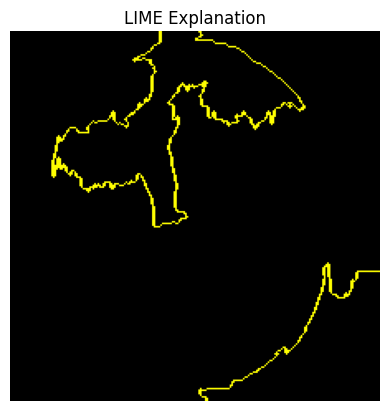

Background shape: torch.Size([10, 3, 224, 224])
Test images shape: torch.Size([5, 3, 224, 224])


SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (5, 3, 224, 224, 3)


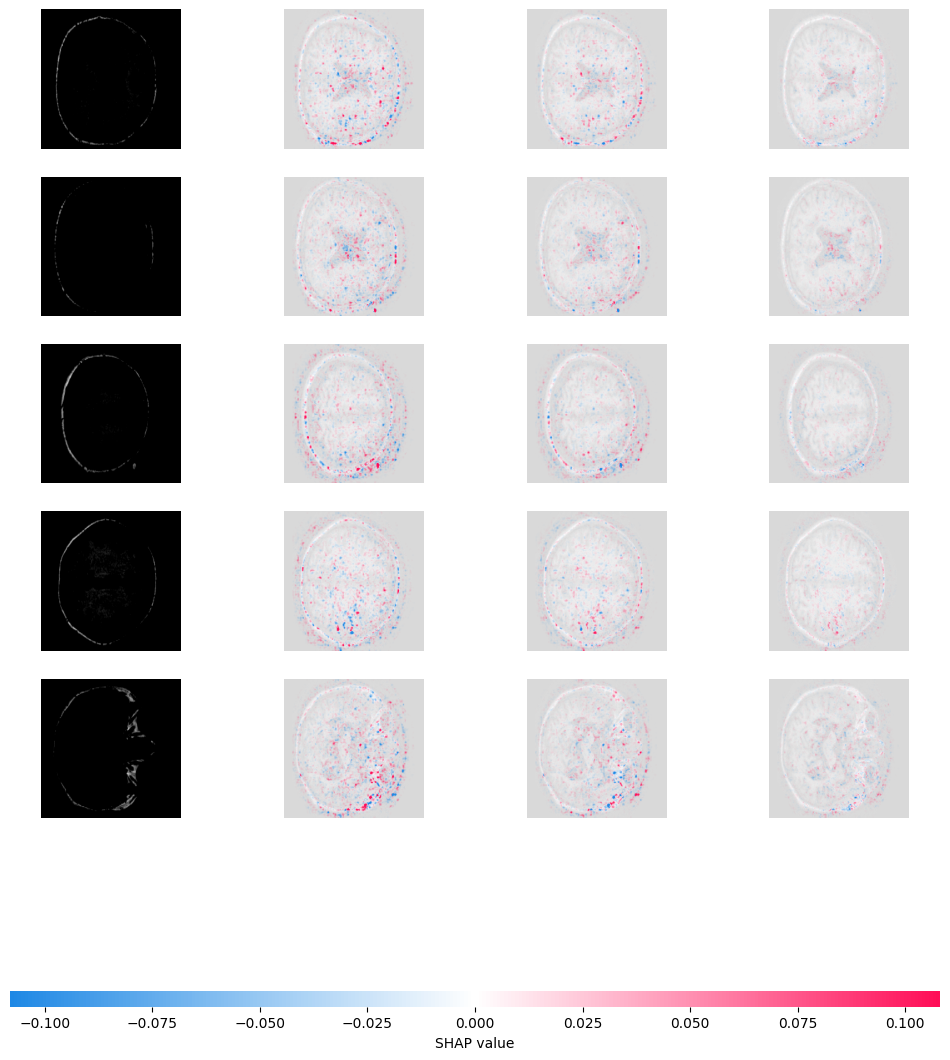

In [24]:
# ---------------------- LIME Explanation ----------------------
def run_lime(model, dataloader, device, transform):
    model.eval()
    explainer = LimeImageExplainer()

    def batch_predict(images):
        # images are numpy arrays from LIME, convert to tensor and apply transform
        batch = torch.stack([transform(transforms.ToPILImage()(img)) for img in images], dim=0).to(device)
        with torch.no_grad():
            outputs = model(batch)
        return outputs.cpu().numpy()

    images, labels = next(iter(dataloader))
    explanation = explainer.explain_instance(
        images[0].permute(1, 2, 0).cpu().numpy(),
        batch_predict,
        top_labels=1, hide_color=0, num_samples=100
    )
    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, hide_rest=False)
    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.title("LIME Explanation")
    plt.axis('off')
    plt.show()

def run_shap(model, dataloader, device):
    model.eval()
    images, _ = next(iter(dataloader))
    background = images[:10].to(device)
    test_images = images[10:15].to(device)

    print("Background shape:", background.shape)
    print("Test images shape:", test_images.shape)

    explainer = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(test_images)

    print("SHAP values type:", type(shap_values))
    print("SHAP values shape:", shap_values.shape)

    # shap_values shape: (batch, classes, height, width, channels)
    # Split along axis=1 (classes) and convert each to (batch, height, width, channels)
    shap_values_per_class = [shap_values[:, i, :, :, :] for i in range(shap_values.shape[1])]

    # Convert test images to channels-last for plotting
    test_images_np = test_images.cpu().numpy().transpose(0, 2, 3, 1)

    shap.image_plot(shap_values_per_class, test_images_np)


# ---------------------- Run Explainability ----------------------
run_lime(model, test_loader, device, transform)
run_shap(model, test_loader, device)

# ---------------------- Save Model ----------------------
torch.save(model.state_dict(), "cnn_transformer_hybrid.pth")

In [26]:
def run_lime_save(model, dataloader, device, transform):
    model.eval()
    explainer = LimeImageExplainer()
    images, labels = next(iter(dataloader))

    def batch_predict(images):
        batch = torch.stack([transform(transforms.ToPILImage()(img)) for img in images], dim=0).to(device)
        with torch.no_grad():
            outputs = model(batch)
        return outputs.cpu().numpy()

    explanation = explainer.explain_instance(
        images[0].permute(1, 2, 0).cpu().numpy(),
        batch_predict,
        top_labels=1, hide_color=0, num_samples=100
    )
    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, hide_rest=False)

    img = mark_boundaries(temp / 255.0, mask)
    img = np.clip(img, 0, 1)  # <-- Clip values before saving

    plt.imsave('lime_explanation.png', img)
    print("Saved LIME explanation to lime_explanation.png")

run_lime_save(model, test_loader, device, transform)

  0%|          | 0/100 [00:00<?, ?it/s]

Saved LIME explanation to lime_explanation.png


In [27]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


In [28]:
from sklearn.metrics import classification_report

def evaluate_full_report(model, dataloader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(classification_report(all_labels, all_preds, target_names=class_names))

evaluate_full_report(model, test_loader, device, dataset.classes)


              precision    recall  f1-score   support

        Data       1.00      1.00      1.00     12967

    accuracy                           1.00     12967
   macro avg       1.00      1.00      1.00     12967
weighted avg       1.00      1.00      1.00     12967



In [29]:
example_input = torch.randn(1, 3, 224, 224).to(device)
traced_script_module = torch.jit.trace(model, example_input)
traced_script_module.save("cnn_transformer_hybrid_script.pt")
print("Model saved as TorchScript.")


Model saved as TorchScript.


In [31]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the saved TorchScript model
loaded_model = torch.jit.load("cnn_transformer_hybrid_script.pt").to(device)
loaded_model.eval()

# Create a dummy input tensor with the same shape your model expects
example_input = torch.randn(1, 3, 224, 224).to(device)

# Run inference
with torch.no_grad():
    output = loaded_model(example_input)

print("Inference output:", output)


Inference output: tensor([[ 4.9866, -2.1865, -2.1953]], device='cuda:0')


In [34]:
from PIL import Image
import torchvision.transforms as transforms
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define your transforms (example)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Full path to the GIF file
image_path = r"/content/OAS1_0001_MR1_mpr_n4_anon_111_t88_masked_gfc_fseg_tra_90.gif"

# Load the GIF, convert to RGB
image = Image.open(image_path).convert("RGB")

# Apply transforms
input_tensor = transform(image).unsqueeze(0).to(device)

print("Image tensor shape:", input_tensor.shape)

Image tensor shape: torch.Size([1, 3, 224, 224])


In [35]:
import torch
from torchvision import transforms
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load TorchScript model
model = torch.jit.load("cnn_transformer_hybrid_script.pt").to(device)
model.eval()

# Define transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load and preprocess your GIF image
image_path = r"/content/OAS1_0001_MR1_mpr_n4_anon_111_t88_masked_gfc_fseg_tra_90.gif"
image = Image.open(image_path).convert("RGB")

input_tensor = transform(image).unsqueeze(0).to(device)

# Run inference
with torch.no_grad():
    output = model(input_tensor)

predicted_class = torch.argmax(output, dim=1).item()
print(f"Predicted class index: {predicted_class}")


Predicted class index: 0


In [36]:
predicted_class = torch.argmax(output, dim=1).item()

class_names = ["Healthy", "Alzheimer's", "Other"]  # Change this to your classes
predicted_label = class_names[predicted_class]

print(f"Predicted class index: {predicted_class}")
print(f"Predicted label: {predicted_label}")

Predicted class index: 0
Predicted label: Healthy


In [37]:
import torch
from torchvision import transforms
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load TorchScript model
model = torch.jit.load("cnn_transformer_hybrid_script.pt").to(device)
model.eval()

# Define transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load and preprocess your GIF image
image_path = r"/content/OAS1_0001_MR1_mpr_n4_anon_111_t88_masked_gfc_fseg_tra_90.gif"
image = Image.open(image_path).convert("RGB")

input_tensor = transform(image).unsqueeze(0).to(device)

# Run inference
with torch.no_grad():
    output = model(input_tensor)

predicted_class = torch.argmax(output, dim=1).item()

# Map class index to human-readable label
class_names = ["Healthy", "Alzheimer's", "Other"]  # update as needed
predicted_label = class_names[predicted_class]

print(f"Predicted class index: {predicted_class}")
print(f"Predicted label: {predicted_label}")

Predicted class index: 0
Predicted label: Healthy
